In [1]:
import numpy as np
import os, sys 
import re
import ROOT
ROOT.gStyle.SetOptStat(0)
import glob
import pandas as pd
from datetime import datetime, timezone
from zoneinfo import ZoneInfo
from uncertainties import *
from uncertainties.umath import exp
import math
import requests
from CDMSDataCatalog import CDMSDataCatalog
from cats.cdataframe import CDataFrame

import matplotlib.pyplot as plt
%matplotlib inline

CDMS = os.environ["CDMS"]
token = os.environ["token"]

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
from ROOplot import ROOplot

import warnings
warnings.filterwarnings("ignore")

Welcome to JupyROOT 6.28/10


In [2]:
y2s = 3.154e7
s2month = 3.80517e-7
s2day = 1.157e-5

#Pb210 radioactive properties
Pb210_halflife = (ufloat(22.20, 0.22)*y2s) # s
Pb210_lifetime = Pb210_halflife / np.log(2) # s
Pb210_lambda   = 1 / Pb210_lifetime

# assume that lambda_a = 0 in these clean room environments
# referencing www.chemlin.org for half lives and uncertainties
tau_0 = ufloat(3.8222, 0.0009)*24 / np.log(2) # Rn222 lifetime [h]
lambda_0 = 1 / tau_0                          # Rn222 decay constant [/h]
tau_1 = ufloat(3.097, 0.012)/60 / np.log(2)   # Po218 lifetime [h]
lambda_1 = 1 / tau_1                          # Po218 decay constant [/h]
tau_2 = ufloat(27.06, 0.07)/60 / np.log(2)    # Pb214 lifetime [h]
lambda_2 = 1 / tau_2                          # Pb214 decay constant [/h]
tau_3 = ufloat(19.71, 0.02)/60 / np.log(2)    # Bi214 lifetime [h]
lambda_3 = 1 / tau_3                          # Bi214 decay constant [/h]

# using the typical value in Knutson for deposition velocity
v_d = ufloat(10, 2) # m / h

In [3]:
def calc_implantation_rate(A_0, lambda_v, SV, frac_implanted=ufloat(0.558, 0.024)):

    lambda_d = SV * v_d # /h

    A_1 = lambda_1 * A_0 / (lambda_1 + lambda_v + lambda_d)
    A_1_s = lambda_d * A_1 / lambda_1
    A_2 = lambda_2 * A_1 / (lambda_2 + lambda_v + lambda_d)
    A_2_s = (lambda_2 * A_1_s + lambda_d * A_2) / lambda_2
    A_3 = lambda_3 * A_2 / (lambda_3 + lambda_v + lambda_d)
    A_3_s = (lambda_3 * A_2_s + lambda_d * A_3) / lambda_3

    R_implanted = A_3_s * frac_implanted / SV # convert from volume-equivalent activity to surface activity
    
    return R_implanted

In [4]:
def integrate_decays(R, N0, T):
    return R*(1 - exp(-Pb210_lambda * T))/Pb210_lambda + N0 * exp(-Pb210_lambda * T)

In [5]:
def effective_exposure(location, subject):
    if subject=='crystal':
        if location.lower()=='suf polishing (tunnel a)':
            return ufloat(0.07, 0.03)
        elif location.lower()=='snf lab (fab)':
            return ufloat(0.007, 0.003)
        elif location.lower()=='b04 lab':
            return ufloat(0.08, 0.02)
        else: return 1
    else: return 1

In [6]:
def integrate_history(dataframe, tf_measure_unix, subject='crystal', verbose_only=False):
    N0 = ufloat(0, 0)
    stop = False

    for i in range(len(dataframe['Condition'])):
        condition_cut = mapping['Condition'] == dataframe['Condition'][i]
        location = df["Location"][i]
        A        = mapping['A_'+subject][condition_cut][0]
        lambda_v = mapping['lambda_v_'+subject][condition_cut][0]
        SV       = mapping['SV_'+subject][condition_cut][0]

        R_implanted = calc_implantation_rate(A, lambda_v, SV) # Pb-214 decays / s / m^2

        t0 = dataframe['TS'][i]
        if tf_measure_unix <= (t0 + dataframe['Elapsed'][i]):
            tf, stop = tf_measure_unix, True
        else:
            tf = t0 + df['Elapsed'][i]

        Nf = integrate_decays(R_implanted, N0, (tf - t0)*effective_exposure(location, subject))

        N0 = Nf
        if stop:
            Af = Nf*1e-4*Pb210_lambda*1e9
            if verbose_only: 
                print(f'Total activity at time ' + datetime.fromtimestamp(tf_measure_unix.n).strftime("%Y-%m-%d %H:%M") + ' is ' + str(Af) + ' nBq / cm^2')
                break
            return Nf

In [7]:
def correlate_values(subject):
    val = np.concatenate([[mapping['A_'+subject][i].n, mapping['lambda_v_'+subject][i].n, mapping['SV_'+subject][i].n] 
                              for i in range(len(mapping['A_'+subject]))])
    std = np.concatenate([[mapping['A_'+subject][i].s, mapping['lambda_v_'+subject][i].s, mapping['SV_'+subject][i].s] 
                              for i in range(len(mapping['A_'+subject]))])

    table_n = {'crystal': -6, 'housing': -5}
    corr_df = pd.read_html(html)[table_n[subject]]
    corr_df = np.concatenate(corr_df.to_numpy())
    corr = []
    for i in corr_df:
        row = [1 if corr_df[j]==i else 0 for j in range(len(corr_df))]
        corr.append(row)

    cov = np.outer(std, std) * corr
    params = correlated_values(val, cov)

    mapping['A_'+subject] = np.array([params[3*i+0] for i in range(len(mapping['A_'+subject]))])
    mapping['lambda_v_'+subject] = np.array([params[3*i+1] for i in range(len(mapping['A_'+subject]))])
    mapping['SV_'+subject] = np.array([params[3*i+2] for i in range(len(mapping['A_'+subject]))])

In [8]:
def is_comment_or_note(row):
    text = " ".join(row.dropna().astype(str)).lower()
    return text.startswith(("comment", "note"))

In [9]:
def date2unix(date, unc):
    return ufloat(int(datetime.strptime(date, "%Y-%m-%d %H:%M").replace(tzinfo=ZoneInfo("America/New_York")).timestamp()), unc)

In [10]:
base_url = "https://confluence.slac.stanford.edu"
page_id = "685801484"

url = f"{base_url}/rest/api/content/{page_id}?expand=body.storage"

headers = {
    "Authorization": f"Bearer {token}",
    "Accept": "application/json"
}

response = requests.get(url, headers=headers)

data = response.json()
html = data["body"]["storage"]["value"]

df = pd.read_html(html)[-4]
df = df[~df.apply(is_comment_or_note, axis=1)].to_dict(orient='list')

mapping = pd.read_html(html)[-8].to_dict(orient='list')

 Clean up dataframes so that they use consistent, shortened keys instead of the more human readable names used on the confluence page

In [11]:
key_rename = {('Location', 'Location'): 'Location',
              ('Condition', 'Condition'): 'Condition',
              ('Activity', 'Crystal'): 'A_crystal',
              ('Activity', 'Housing'): 'A_housing',
              ('Ventilation rate', 'Crystal'): 'lambda_v_crystal',
              ('Ventilation rate', 'Housing'): 'lambda_v_housing',
              ('Surface-Volume ratio', 'Crystal'): 'SV_crystal',
              ('Surface-Volume ratio', 'Housing'): 'SV_housing'}

df.pop('Reference')
df.pop('Comments/SI')
df['TS unc'] = df.pop('Timestamp uncertainty (h)')
df['TS'] = df.pop('Timestamp')
for key in list(mapping.keys()): mapping[key_rename[key]] = np.array(mapping.pop(key))
for key in list(mapping.keys()): mapping[key] = mapping[key][mapping[key]!='nan']
for key in ['A_crystal', 'A_housing', 'lambda_v_crystal', 'lambda_v_housing', 'SV_crystal', 'SV_housing']:
    mapping[key] = np.array([ufloat_fromstr(i) for i in mapping[key]])

correlate_values('crystal')
correlate_values('housing')

### Convert timestamps into unix time

In [60]:
end_date = "2026-03-21 00:00"
end_date_unix = date2unix(end_date, 0)

df['TS unc'] = np.array([float(i)*60*60 for i in df['TS unc']])
df['TS'] = np.array([int(date2unix(i, 0).n) for i in df['TS']])
df['TS'] = np.array([ufloat(df['TS'][i], df['TS unc'][i]) for i in range(len(df['TS']))])
df['TS'] = np.append(df['TS'], end_date_unix)
df['Elapsed'] = np.array([df['TS'][i+1] - df['TS'][i] for i in range(len(df['TS']) - 1)])

# Activity accumulation on crystal

In [61]:
tf_measure = '2023-10-19 15:23'
tf_measure_unix = date2unix(tf_measure, 15*60)
integrate_history(tf_measure_unix, subject='crystal', verbose_only=True)

Total activity at time 2023-10-19 12:23 is 31+/-10 nBq / cm^2


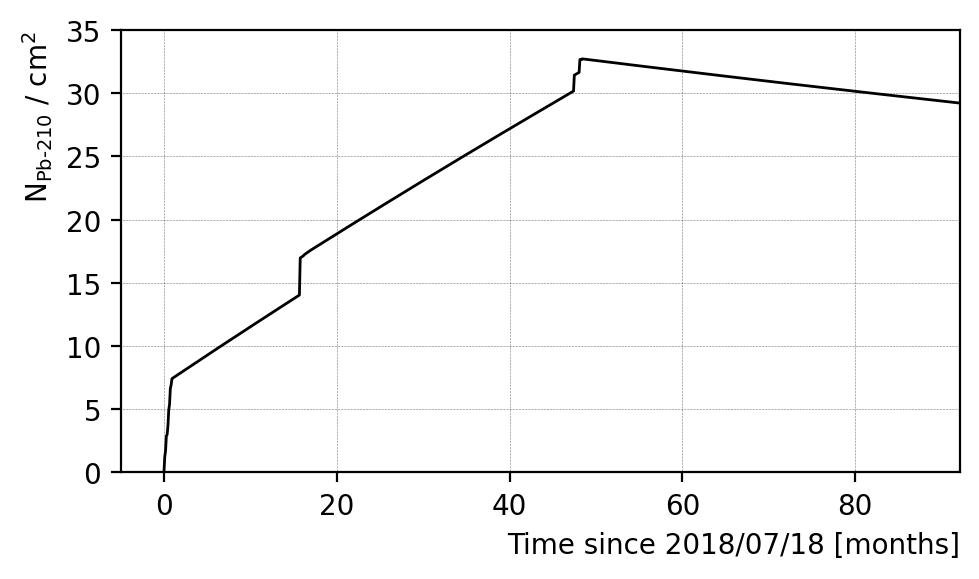

In [63]:
# Window for plotting
window_start = df['TS'][0].n
window_end = end_date_unix.n
t = np.linspace(window_start, window_end, 1000)
t_float = np.array([ufloat(i, 0) for i in t])

plt.figure(figsize=(5,3), dpi=200)
N = np.array([integrate_history(tf, subject='crystal', verbose_only=False).n for tf in t_float])

plt.plot((t - window_start)*s2month, N*1e-4, color = 'black', lw = 1)
plt.xlim(-5, (window_end-window_start)*s2month)
plt.ylim(0, 35)
plt.grid(True, color = 'black', lw = 0.2, ls = 'dotted')
plt.xlabel(f'Time since {datetime.fromtimestamp(window_start).strftime("%Y/%m/%d")} [months]', loc = 'right')
plt.ylabel(r'N$_{\text{Pb-210}}$ / cm$^2$', loc = 'top')
plt.tight_layout()

# Activity accumulation on Housing

### Create table for housing traveller history. Calculate elapsed time at each location.

In [18]:
housing = {}
start_entry = 73 # row index where packaging started
entries = len(df['TS'][start_entry:]) # ignore rows where we didn't have housing information

housing['TS'] = df['TS'][start_entry:]

housing['elapsed'] = [(housing['TS'][i+1] - housing['TS'][i]) for i in range(entries-1)]
housing['elapsed'].append(end_data_unix - housing['TS'][-1])
housing['elapsed'] = np.array(housing['elapsed'])

housing['Condition'] = np.array(df['Condition'][start_entry:])
housing['Location'] = np.array(df['Location'][start_entry:])

# insert an initial entry where the freshly-etched housing was put into a purge box before packaging
storage_date = "2019-03-27 00:00"
storage_date_unix = ufloat(int(datetime.strptime(storage_date, "%Y-%m-%d %H:%M").replace(tzinfo=ZoneInfo("America/New_York")).timestamp()), 60*60*24)
housing['TS'] = np.insert(housing['TS'], 0, storage_date_unix)
housing['elapsed'] = np.insert(housing['elapsed'], 0, housing['TS'][1] - housing['TS'][0])
housing['Location'] = np.insert(housing['Location'], 0, 'Purged storage')
housing['Condition'] = np.insert(housing['Condition'], 0, 'suf_storage')

### Create separate table of total elapsed time that housing spent in each condition. 

In [19]:
housing_elapsed = {}

for condition in np.unique(housing['condition']):
    housing_elapsed[condition] = sum(housing['elapsed'][housing['condition']==condition])

### Writing a correlation matrix for the parameters we will use for this calculation

In [31]:
val_housing = np.concatenate([[mapping['A_housing'][i].n, mapping['lambda_v_housing'][i].n, mapping['SV_housing'][i].n] 
                              for i in range(len(mapping['Condition']))])
std_housing = np.concatenate([[mapping['A_housing'][i].s, mapping['lambda_v_housing'][i].s, mapping['SV_housing'][i].s] 
                              for i in range(len(mapping['Condition']))])

std_housing = std_housing[~np.isnan(val_housing)]
val_housing = val_housing[~np.isnan(val_housing)]

In [32]:
corr_df_housing = pd.read_html(html)[-5]
corr_df_housing = np.concatenate(corr_df_housing.to_numpy())
corr_housing = []
for i in corr_df_housing:
    row = [1 if corr_df_housing[j]==i else 0 for j in range(len(corr_df_housing))]
    corr_housing.append(row)

In [33]:
cov_housing = np.outer(std_housing, std_housing) * corr_housing
params_housing = correlated_values(val_housing, cov_housing)

In [35]:
N_implanted = 0
housing_cuts = mapping['Condition']=='suf_polishing'
housing_cuts = housing_cuts | (mapping['Condition']=='snf')
housing_cuts = housing_cuts | (mapping['Condition']=='b04')

print(f"{'Condition':>25} {'Rate (atoms / s / m^2)':>20} {'Elapsed time [h]':>20} {'Implanted atoms / m^2':>20}")
for i, condition in enumerate(mapping['Condition'][~housing_cuts]):
    R_implanted = calc_implantation_rate(params_housing[3*i+0], params_housing[3*i+1], params_housing[3*i+2]) # Pb-214 decays / s / m^2
    t_elapsed = housing_elapsed[condition]
    N_implanted += R_implanted * t_elapsed
    print(f"{condition:>25} {round(R_implanted.nominal_value,1):>20} {round(t_elapsed.nominal_value/60/60,1):>20} {round(R_implanted.nominal_value * t_elapsed.nominal_value,1):>20}")

print(f'Total accumulated activity {N_implanted*1e-4*Pb210_lambda*1e9} nBq / cm^2')

                Condition Rate (atoms / s / m^2)     Elapsed time [h] Implanted atoms / m^2
              suf_storage                  0.0              29106.3             189657.9
                      rsf                  0.5                 11.7              22167.8
     suf_storage_packaged                  0.0                153.1                997.5
                   b33_cr                  1.6                 13.3              75882.0
              b33_storage                  0.0                  4.9                 31.8
       b33_bench_assembly                  0.2                  0.9                682.1
  b33_bench_post_assembly                  0.2                  2.8               2147.3
                   vacuum                  0.0               4047.9                  0.0
        storage_container                  0.0              18785.8               3566.8
                  CUTE_cr                  1.3                  5.5              26295.0
         CUTE_cr_s

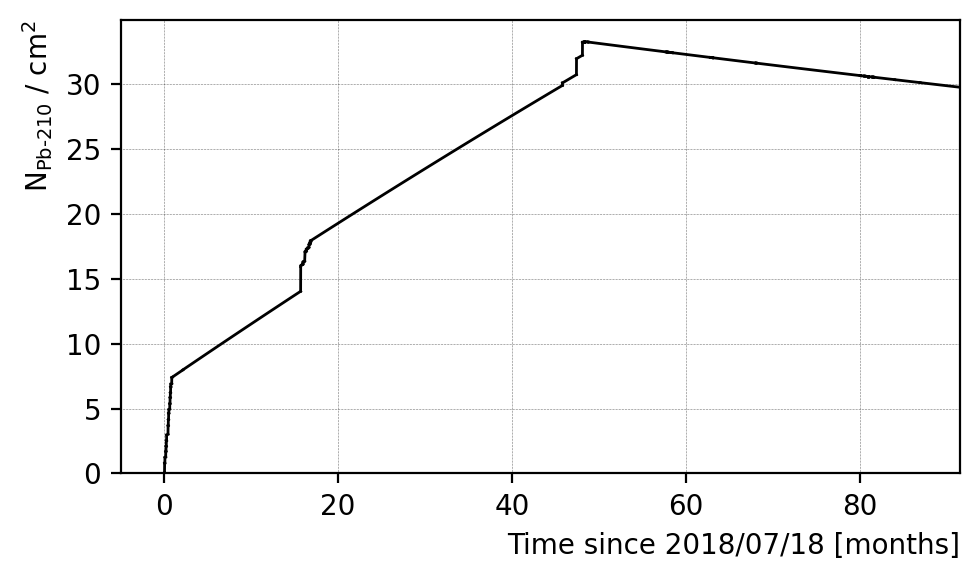

In [59]:
# initial number of implanted Pb-210
N0 = 0
t_crystal = []
N_crystal = []

# Window for plotting
window_start = df['TS'][0].n
window_end = datetime(2026, 3, 3, 0, 0, 0).replace(tzinfo=ZoneInfo("America/New_York")).timestamp()

plt.figure(figsize=(5,3), dpi=200)

for i in range(len(df['TS'])):
    
    condition_cut = mapping['Condition'] == df['Condition'][i]
    
    location, A_0, lambda_v, SV = (df["Location"][i], 
                                   mapping['A_crystal'][condition_cut][0], 
                                   mapping['lambda_v_crystal'][condition_cut][0], 
                                   mapping['SV_crystal'][condition_cut][0])
    
    R_implanted = calc_implantation_rate(A_0, lambda_v, SV).n # Pb-214 decays / s / m^2

    # number of implanted nuclei (N) vs. time (t)
    
    t0 = df['TS'][i].n
    tf = t0 + crystal['elapsed'][i].n
    t = np.linspace(t0, tf, 100)
    
    if location.lower() == 'suf polishing (tunnel a)': # crystal only exposed to air 5% of the time
        Nf = integrate_decays(R_implanted, N0, (t - t0)*0.07)
    elif location.lower() == 'b04 lab': # crystal only exposed to air for 5-10 min or about 0.5% of the time.
        Nf = integrate_decays(R_implanted, N0, (t - t0)*0.007)
    elif location.lower() == 'snf lab (fab)': # crystal only exposed to air for 6 hrs or about 8% of the time.
        Nf = integrate_decays(R_implanted, N0, (t - t0)*0.08)
    else:
        Nf = integrate_decays(R_implanted, N0, t - t0)

    t_crystal.append((t - window_start)*s2month)
    N_crystal.append(Nf*1e-4)

    #### plot implanted nuclei vs. time at start of window ####
    plt.plot((t - window_start)*s2month, Nf*1e-4, color = 'black', lw = 1)
    
    N0 = Nf[-1]

plt.xlim(-5, (window_end-window_start)*s2month)
plt.ylim(0, None)
plt.grid(True, color = 'black', lw = 0.2, ls = 'dotted')
plt.xlabel(f'Time since {datetime.fromtimestamp(window_start).strftime("%Y/%m/%d")} [months]', loc = 'right')
plt.ylabel(r'N$_{\text{Pb-210}}$ / cm$^2$', loc = 'top')
plt.tight_layout()

t_crystal = np.concatenate(t_crystal)
N_crystal = np.concatenate(N_crystal)

27+/-19
Vacuum SNOBOX


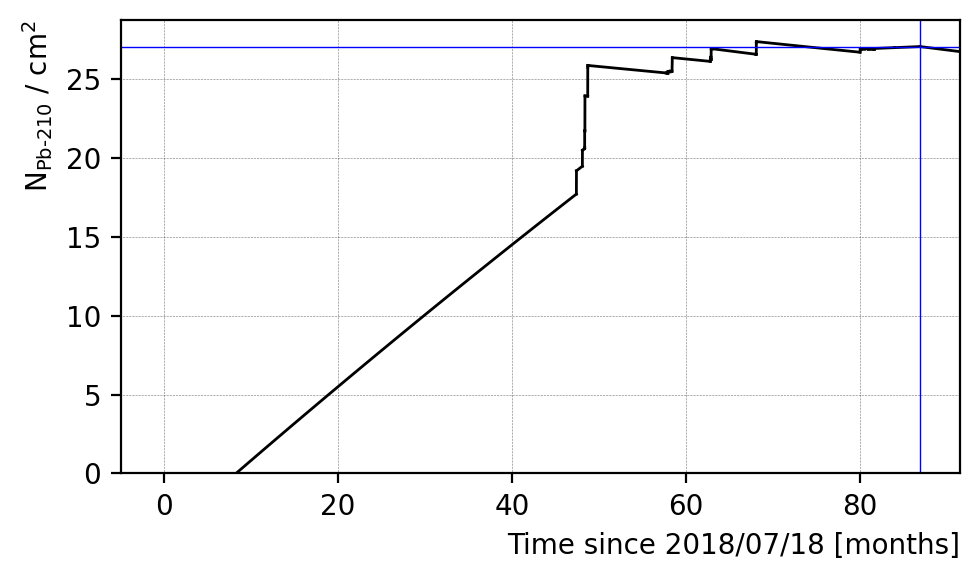

In [14]:
# initial number of implanted Pb-210
N0 = ufloat(0, 0)
t_housing = []
N_housing = []

# Window for plotting
window_start = crystal['ts'][0].nominal_value
window_end = datetime(2026, 3, 3, 0, 0, 0).replace(tzinfo=ZoneInfo("America/New_York")).timestamp()

plt.figure(figsize=(5,3), dpi=200)

for i in range(len(housing['ts'])):
    location, A_0, lambda_v, SV = housing["location"][i], housing["A0"][i], housing["lambda_v"][i], housing["SV"][i]
    R_implanted = calc_implantation_rate(A_0, lambda_v, SV) # Pb-214 decays / s / m^2

    # number of implanted nuclei (N) vs. time (t)
    t0 = housing['ts'][i]
    tf = t0 + housing['elapsed'][i]
    Nf = integrate_decays(R_implanted, N0, tf - t0)

    # use nominal values for plotting
    t = np.linspace(t0.nominal_value, tf.nominal_value, 100)
    N = integrate_decays_nominal(R_implanted, N0, t - t0)
    t_housing.append((t - window_start)*s2month)
    N_housing.append(N*1e-4)

    #### plot implanted nuclei vs. time at start of window ####
    plt.plot((t - window_start)*s2month, N*1e-4, color = 'black', lw = 1)
    if i == 107:
        print(location)
        plt.axvline((t0.nominal_value - window_start)*s2month, 0, 1, lw = 0.5, color = 'b')
        plt.axhline(N0.nominal_value*1e-4, 0, 1, lw = 0.5, color = 'b')
        
    if location=='CUTE Vacuum':
        print(Pb210_lambda*N0*1e-4*1e9)
    N0 = Nf

plt.xlim(-5, (window_end-window_start)*s2month)
plt.ylim(0, None)
plt.grid(True, color = 'black', lw = 0.2, ls = 'dotted')
plt.xlabel(f'Time since {datetime.fromtimestamp(window_start).strftime("%Y/%m/%d")} [months]', loc = 'right')
plt.ylabel(r'N$_{\text{Pb-210}}$ / cm$^2$', loc = 'top')
plt.tight_layout()

t_housing = np.concatenate(t_housing)
N_housing = np.concatenate(N_housing)

#plt.savefig("G157_hist.png")

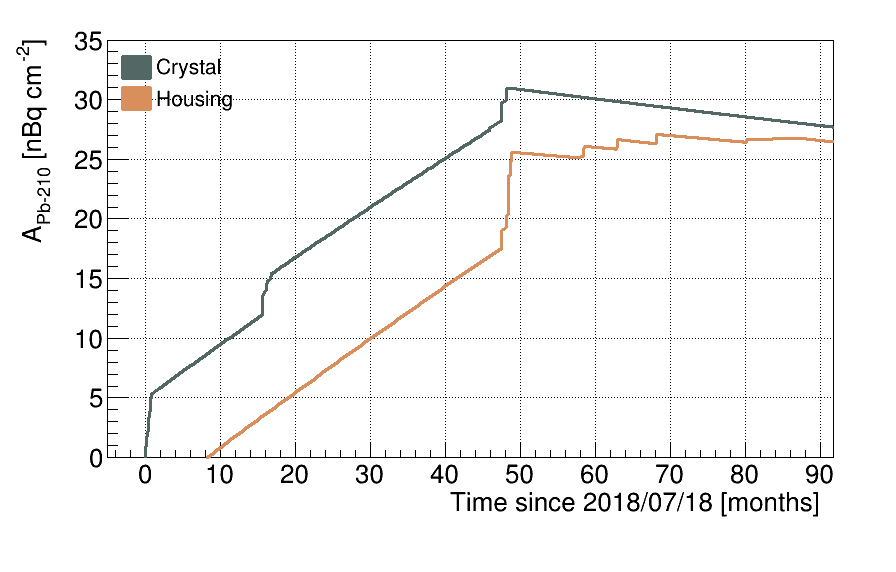

In [15]:
plot = ROOplot(_width=900, _height=600, _xlabel=f'Time since {datetime.fromtimestamp(window_start).strftime("%Y/%m/%d")} [months]', 
               _ylabel="A_{Pb-210} [nBq cm^{-2}]", _leftMargin=0.12, _rightMargin=0.07,
               _xlim=True, _xlow = -5, _xhigh=max(t_crystal),
               _ylim=True, _ylow = 0, _yhigh = 35)
color_crystal = ROOT.TColor.GetColor('#536765')
color_housing = ROOT.TColor.GetColor('#D98F5C')
plot.createScatter(t_crystal, Pb210_lambda.nominal_value * N_crystal * 1e9, color = color_crystal, width=3, label = 'Crystal')
plot.createScatter(t_housing, Pb210_lambda.nominal_value * N_housing * 1e9, color = color_housing, width=3, label = 'Housing')

graphs = plot.getGraphs()
plot.draw("AL", "L ", grid=True)

legend = ROOT.TLegend(0.13, 0.8, 0.5, 0.91)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
for g, label in graphs:
    legend.AddEntry(g, label, "f")
legend.SetTextSize(0.04)
legend.SetEntrySeparation(0.01)
legend.SetMargin(0.12)

legend.Draw()

In [18]:
# Z1 low bg 50V
series_list=['23240109_075338', '23240109_021236', 
'23240108_203134', '23231221_101235', 
'23231221_015705', '23231220_190923', 
'23231220_122140', '23231220_053358', 
'23231220_012745', '23231219_184002', 
'23231219_110331', '23231219_034952', 
'23231218_223530', '23231218_190035', 
'23231218_152721', '23231218_093255', 
'23231218_024511', '23231217_212512', 
'23231217_171613', 
'23231217_135018', '23231216_233807', 
'23231216_211119', '23231216_194929', 
'23231216_182937', '23231216_173436', 
'23231216_145300', '23231216_100125', 
'23231216_043946', '23231216_013604'] # Ge calibration

In [19]:
ProdTag = 'CUTE_T3GeCalib_NxM_P4.0.0_V05-06_C0.3.6'

In [20]:
## Use DataCat to pull the series
dc = CDMSDataCatalog().findData(
    Facility    = "CUTE",
    nFridgeRun  = 37,
    Series      = series_list,
    ProdTag     = ProdTag,
    nMergeLevel = 1,
    dofetch     = True
)
filepath = [x.filePath for x in dc]

In [21]:
det = 1 # detector number

df = CDataFrame("rqDir/zip"+str(det), filepath, friends = [[x+":rqDir/eventTree" for x in filepath]])

In [22]:
RQs = (["SeriesNumber", "PTOFamps", "EventNumber", "EventTime"])
df_filtered = df.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(det), "PTOFamps>0"])
df_rqs = df_filtered.AsNumpy(RQs)

In [23]:
N0 = ufloat(30, 15) # atoms / cm^2
t0 = ufloat(1697743380, 900) # timestamp in unix eastern

#### track change in number of Pb-210 nuclei during and after exposures ####
N_tot = 0
for sn in np.unique(df_rqs['SeriesNumber']):
    snCut = df_rqs['SeriesNumber'] == sn
    evtTimes = df_rqs['EventTime'][snCut]
    sn_start = min(evtTimes)
    sn_end = max(evtTimes)

    N_start = N0 * exp(-Pb210_lambda * (sn_start - t0))
    N_end = N0 * exp(-Pb210_lambda * (sn_end - t0))

    N_tot += N_start - N_end
    print(f'{sn}: {N_tot}')

print()
print('{:+.3uS} total Pb-210 events'.format(N_tot*261.79) )

23231216013604.0: 0.00029+/-0.00015
23231216043946.0: 0.0008+/-0.0004
23231216100125.0: 0.0009+/-0.0004
23231216145300.0: 0.0012+/-0.0006
23231216173436.0: 0.0013+/-0.0006
23231216182937.0: 0.0014+/-0.0007
23231216194929.0: 0.0014+/-0.0007
23231216211119.0: 0.0015+/-0.0008
23231216233807.0: 0.0016+/-0.0008
23231217135018.0: 0.0019+/-0.0009
23231217171613.0: 0.0023+/-0.0011
23231217212512.0: 0.0028+/-0.0014
23231218024511.0: 0.0035+/-0.0017
23231218093255.0: 0.0039+/-0.0020
23231218152721.0: 0.0042+/-0.0021
23231218190035.0: 0.0044+/-0.0022
23231218223530.0: 0.0049+/-0.0025
23231219034952.0: 0.0057+/-0.0029
23231219110331.0: 0.0064+/-0.0032
23231219184002.0: 0.007+/-0.004
23231220012745.0: 0.008+/-0.004
23231220053358.0: 0.008+/-0.004
23231220122140.0: 0.009+/-0.004
23231220190923.0: 0.010+/-0.005
23231221015705.0: 0.010+/-0.005
23231221101235.0: 0.010+/-0.005
23240108203134.0: 0.011+/-0.005
23240109021236.0: 0.011+/-0.006
23240109075338.0: 0.012+/-0.006

+3.01(1.51) total Pb-210 events